In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import interp1d
from scipy.interpolate import splrep, splev
import astropy
import os
from astropy.io import fits
import astropy.units as u
from scipy.signal import savgol_filter, argrelextrema
from scipy.optimize import curve_fit

In [2]:
srt_file="lab3kore.rad"
infile = open(srt_file)
for line in infile.readlines():
    print(line)

* STATION LAT=  43.07 DEG LONGW=  89.41

* kore.cmd: line 1 : record lab3kore.rad

2024:311:21:49:50    0.0   0.0   0.0   0.0  1419.75 0.00781250   1  64  28.0  36.0  62.0 124.0 239.0 431.0 741.0 957.0 1304.3 1307.8 1309.1 1313.7 1331.8 1323.6 1314.0 1316.1 1308.8 1250.8 1288.3 1304.0 1287.4 1330.2 1315.3 1282.1 1319.2 1275.7 1347.4 1280.4 1318.6 1305.6 1326.6 1302.8 1329.0 1333.6 1321.7 1297.9 1306.2 1318.6 1345.5 1318.3 1309.1 1288.2 1295.8 1259.6 1300.2 1281.6 1310.8 1296.3 1345.1 1285.4 1327.4 1307.4 1293.3 1274.0 1306.2 1280.0 1320.8 877.0 638.0 426.0 235.0 121.0  61.0  36.0

* kore.cmd: line 2 : freq 1420.3 4

2024:311:21:49:58    0.0   0.0   0.0   0.0  1419.69 0.00781250   4 156  34.3  41.1  66.9 132.7 242.5 426.3 730.1 947.9 1330.2 1290.7 1304.6 1300.3 1293.2 1317.2 1316.5 1332.8 1299.8 1331.9 1325.3 1296.8 1285.7 1306.2 1326.4 1308.4 1282.3 1321.7 1298.3 1317.6 1280.4 1364.8 1305.4 1331.8 1297.0 1282.8 1332.1 1288.7 1273.1 1282.3 1338.5 1308.1 1342.0 1307.0 1307.2 1288.7 1299.

# Part 1

In [4]:
intensities_per_offset = {}
offsets = []

srt_file="lab3kore.rad"
infile = open(srt_file)

start_reading = False
current_offset = None

for line in infile.readlines():

    if "* kore.cmd: line 35 : galactic 76 0" in line:
        break

    if "galactic" in line:
        # extract the offset
        current_offset = int(line.strip().split()[6])
        offsets.append(current_offset)
        intensities_per_offset[current_offset] = []
        start_reading = False

    if ":300" in line:
        start_reading = True
        continue

    if start_reading and current_offset:
        line_list = line.strip().split()
        intensity = np.array(line_list[9:165], dtype=float)
        if len(intensity) != 0:
            intensities_per_offset[current_offset].append(intensity)
           
infile.close()

intensities_per_offset

{20: [array([ 11.7,  15.2,  29.8,  61.2, 117.3, 208.1, 381.8, 483.8, 657.1,
         660.3, 657.3, 651.8, 667. , 661.6, 639.6, 671. , 677.1, 652.4,
         660.3, 645.1, 643.6, 666.2, 661.4, 642.2, 661.7, 663.5, 661.5,
         651.1, 664.1, 650.2, 657.3, 657.8, 659.7, 654. , 665.8, 681.9,
         667.9, 651.2, 679.7, 660.6, 648.6, 668.7, 662.3, 674.6, 645.8,
         634.9, 640.4, 665. , 654.5, 677.4, 644.4, 661.5, 654.9, 662.9,
         652.3, 654.3, 667.7, 656.1, 654.2, 674.1, 668.4, 660.1, 662.4,
         671.2, 648.9, 669.7, 667.4, 666.2, 652.8, 666.9, 666.8, 660.7,
         666.9, 665.5, 658.3, 670.7, 664.4, 651.1, 669.8, 661.8, 664.7,
         679.2, 658.8, 673.7, 678.6, 666.7, 662.8, 660.1, 667.4, 657.6,
         655.3, 655.1, 648.1, 652.3, 652.2, 650.5, 660. , 643.3, 659.8,
         684.6, 662.6, 666.4, 644.8, 641.5, 633.8, 647.4, 646.5, 646.3,
         650.5, 644.1, 665.3, 649.5, 671.9, 644.2, 638.5, 657.7, 631.6,
         661.8, 629.5, 654.8, 642.8, 659.9, 644.2, 646.1, 65

In [5]:
for offset, arrays_list in intensities_per_offset.items():
    dict = {}
    dict["intensity"] = np.array(arrays_list)
    intensities_per_offset[offset] = dict

In [6]:
freq_vals = np.array(1419.79 + np.arange(0, 156) * 0.0078125)

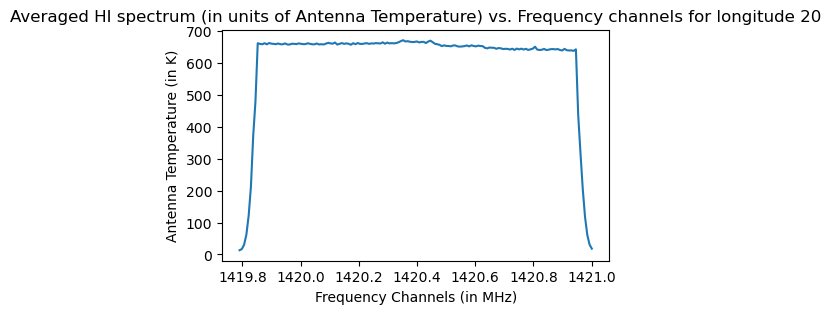

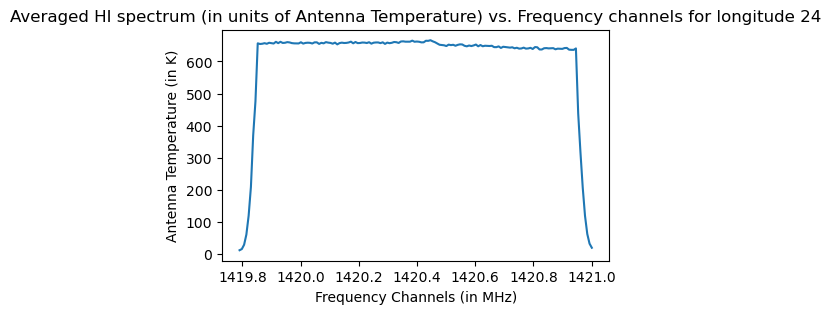

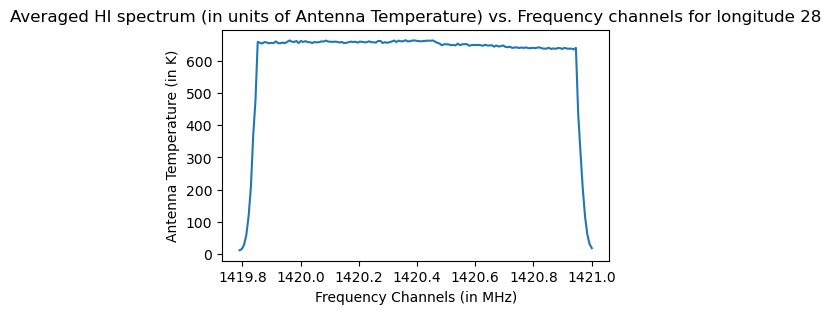

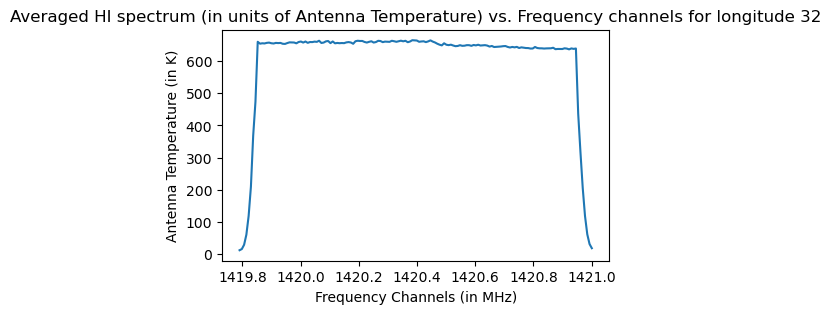

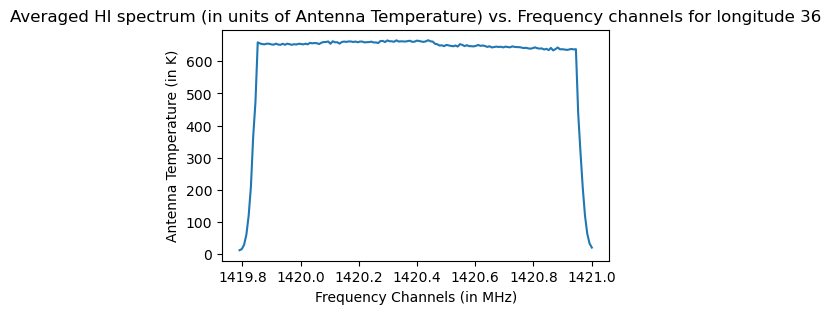

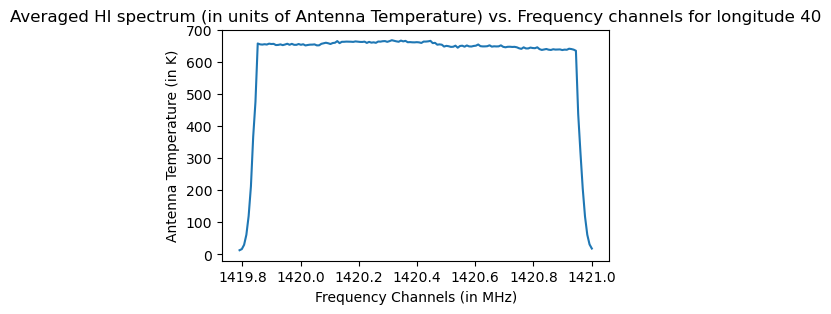

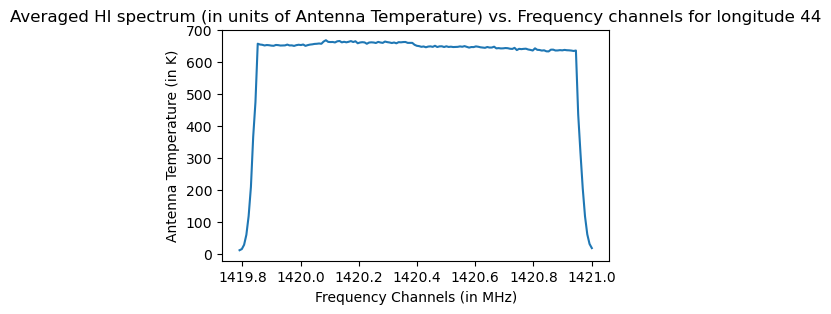

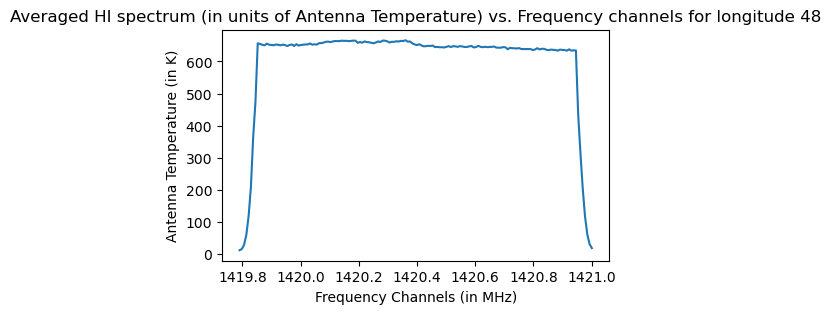

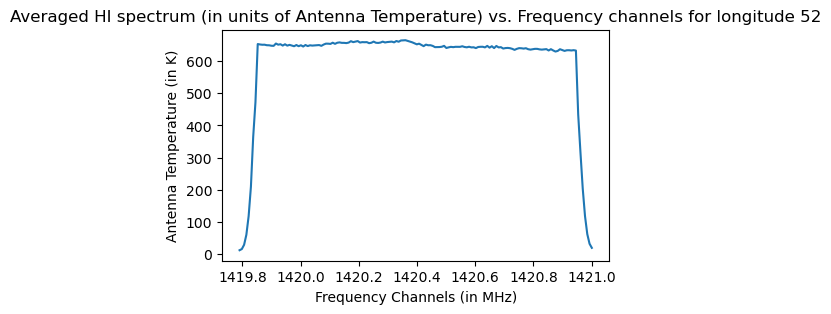

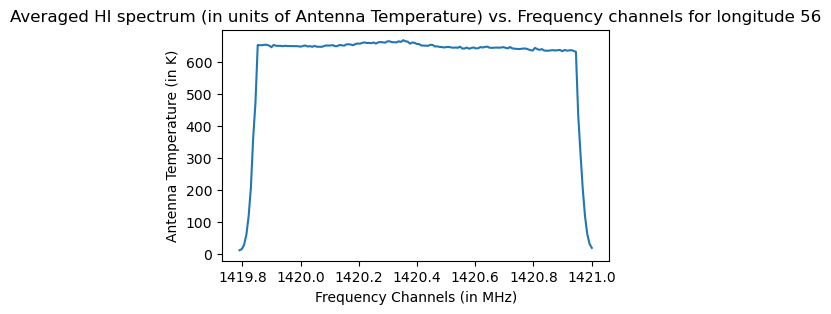

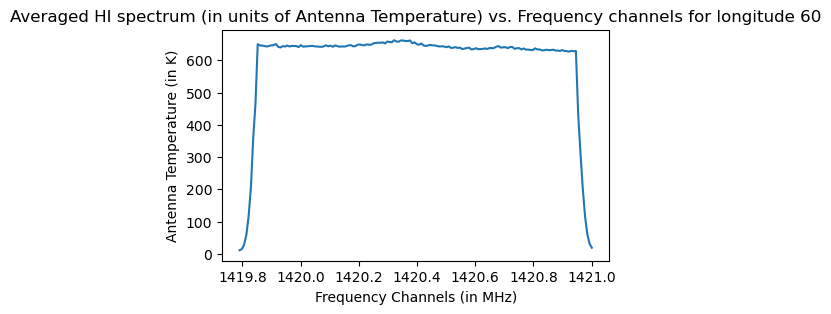

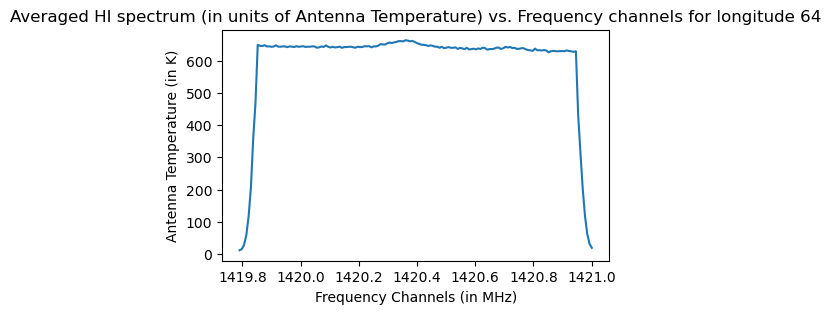

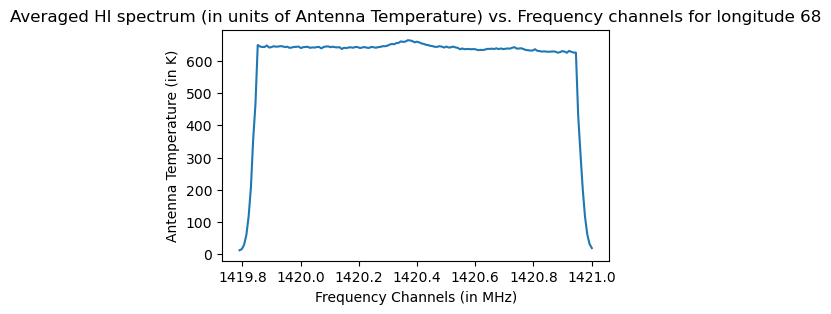

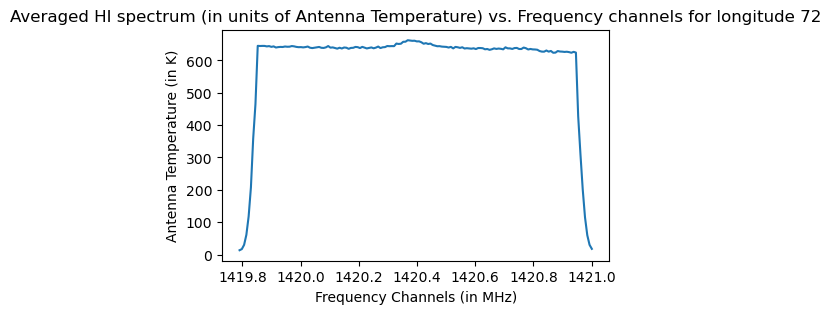

In [7]:
for offset in intensities_per_offset.keys():
    averaged_spec = np.mean(intensities_per_offset[offset]["intensity"], axis = 0)
    intensities_per_offset[offset]["avg intensity"] = averaged_spec
    plt.figure(figsize = (5,3))
    plt.plot(freq_vals, averaged_spec)
    plt.xlabel("Frequency Channels (in MHz)")
    plt.xlim()
    plt.ylabel("Antenna Temperature (in K)")
    plt.title(f"Averaged HI spectrum (in units of Antenna Temperature) vs. Frequency channels for longitude {offset}")
    plt.show()

# Part 2

In [11]:
c = 3e8
rest_frequency = 1420.405751

topocentric_r_velocity = np.array(c * ((rest_frequency - freq_vals)/ rest_frequency))
topocentric_r_velocity = topocentric_r_velocity / 1000

In [12]:
for offset in intensities_per_offset.keys():
    intensities_per_offset[offset]["topocentric r velocity"] = topocentric_r_velocity
    intensities_per_offset[offset]["frequency"] = freq_vals

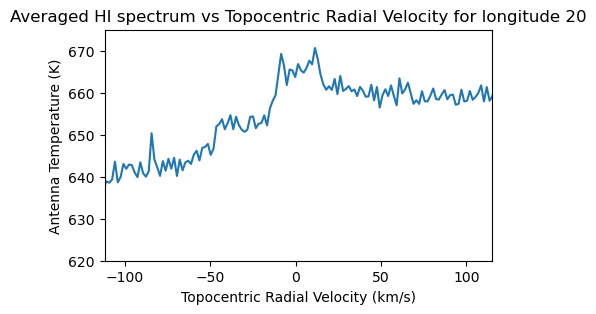

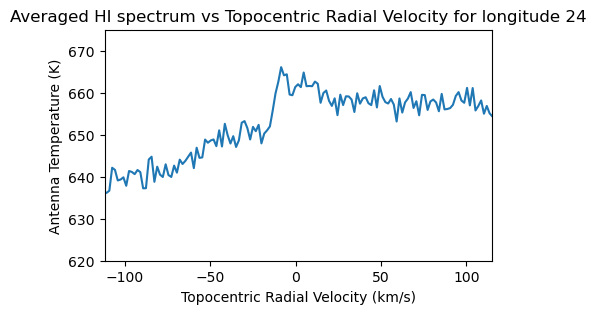

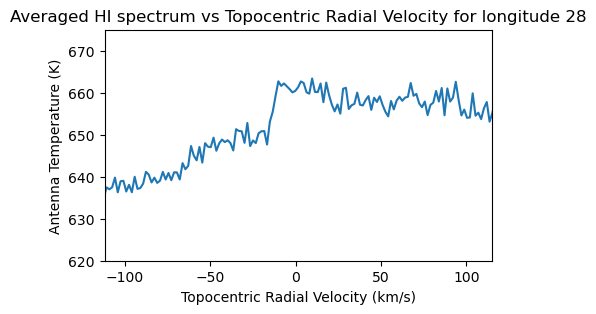

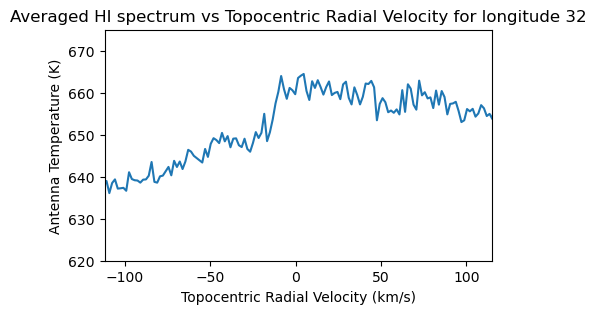

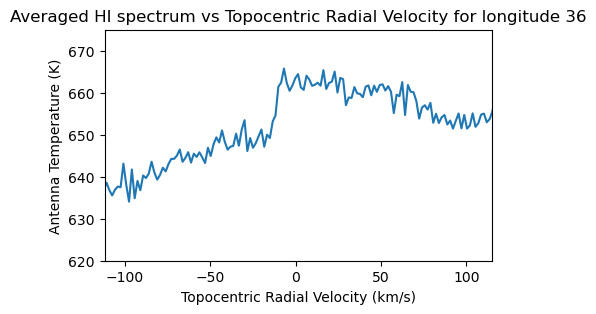

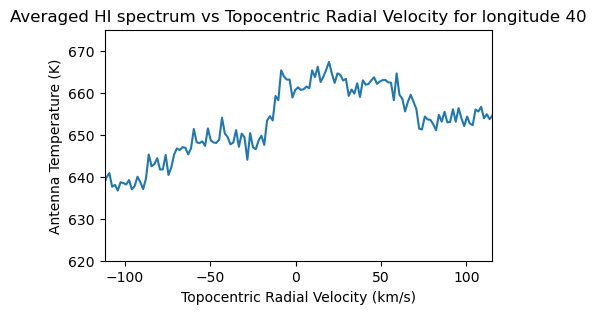

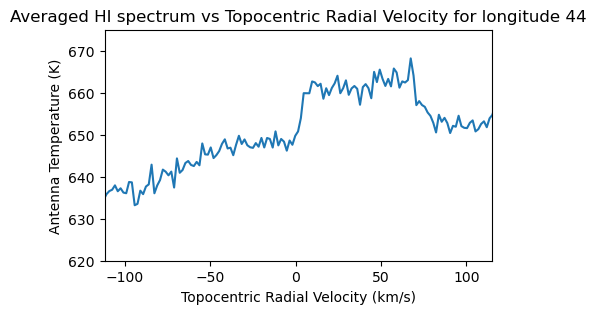

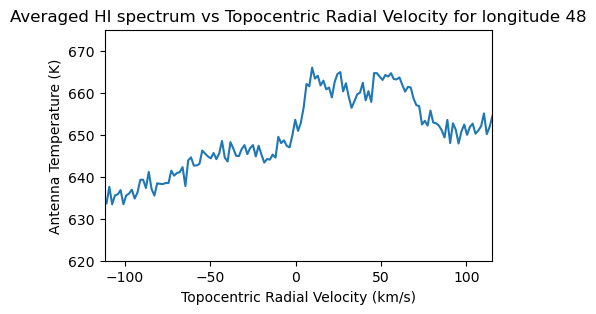

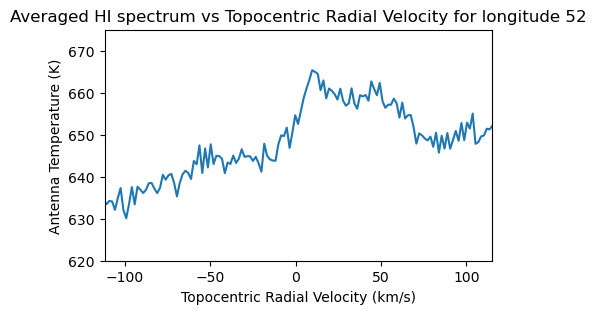

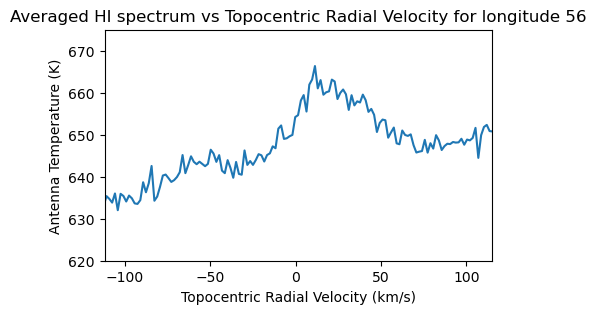

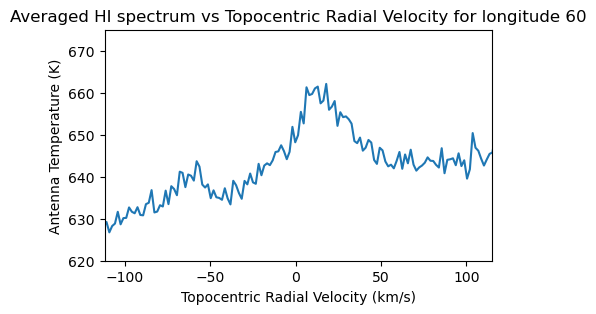

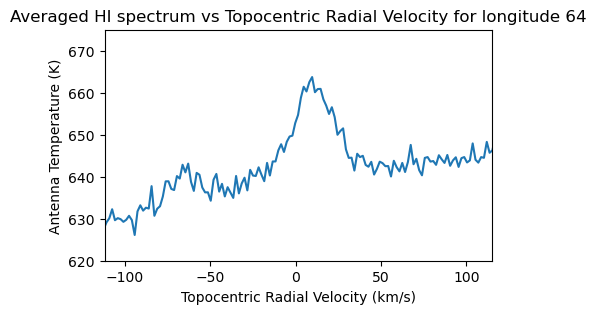

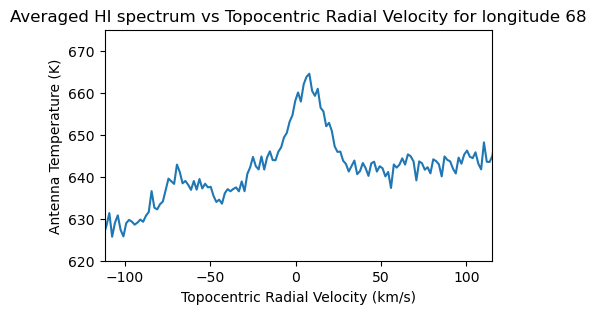

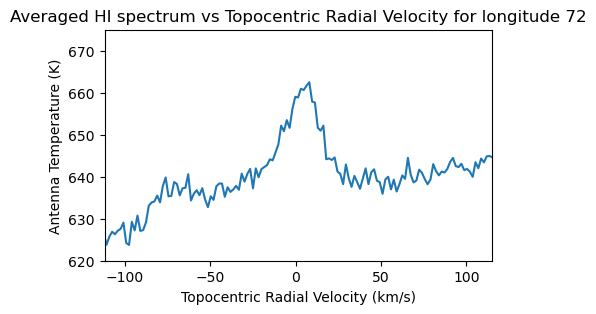

In [13]:
for offset in intensities_per_offset.keys():
    plt.figure(figsize = (5,3))
    plt.plot(intensities_per_offset[offset]["topocentric r velocity"], intensities_per_offset[offset]["avg intensity"])
    plt.xlim(-112, 115)
    plt.ylim(620, 675)
    plt.xlabel("Topocentric Radial Velocity (km/s)")
    plt.ylabel("Antenna Temperature (K)")
    plt.title(f"Averaged HI spectrum vs Topocentric Radial Velocity for longitude {offset}")
    plt.show()

In [14]:
indices_to_include = np.logical_and(topocentric_r_velocity > -112, topocentric_r_velocity < 115)

In [15]:
for offset in intensities_per_offset.keys():
    intensities_per_offset[offset]["topocentric r velocity"] = intensities_per_offset[offset]["topocentric r velocity"][indices_to_include]
    intensities_per_offset[offset]["avg intensity"] = intensities_per_offset[offset]["avg intensity"][indices_to_include]
    intensities_per_offset[offset]["frequency"] = intensities_per_offset[offset]["frequency"][indices_to_include]

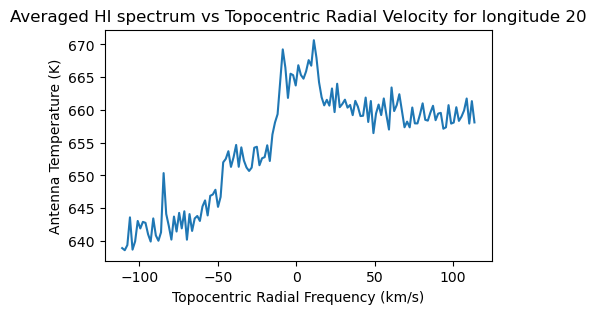

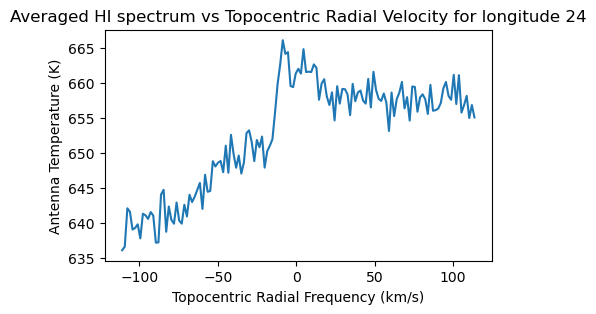

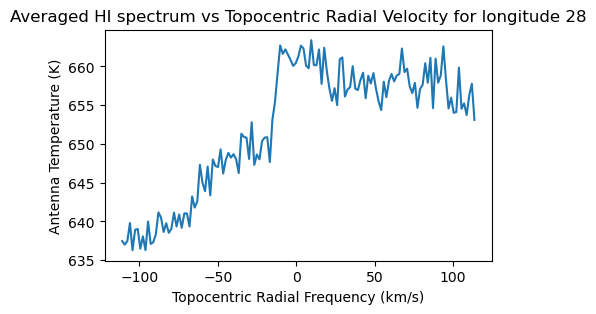

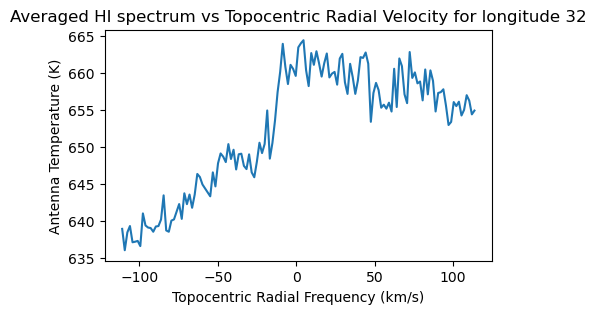

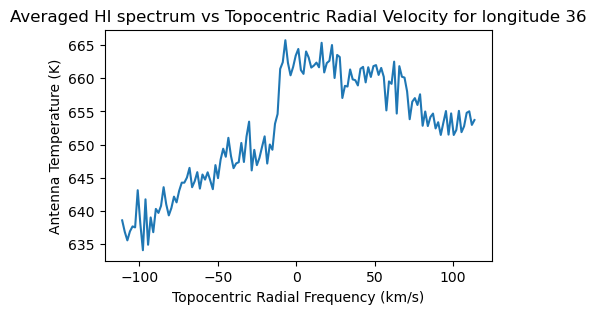

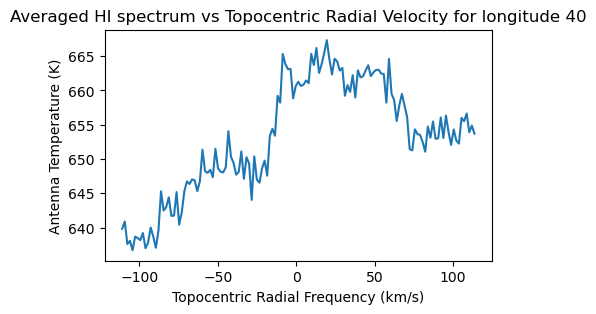

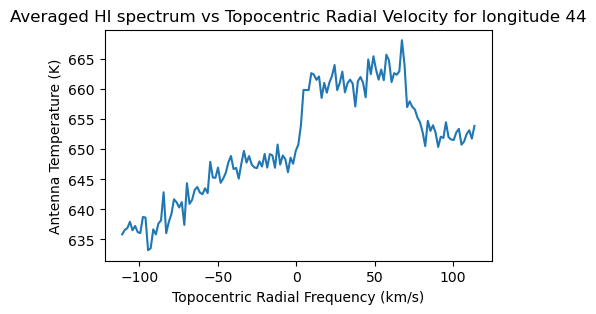

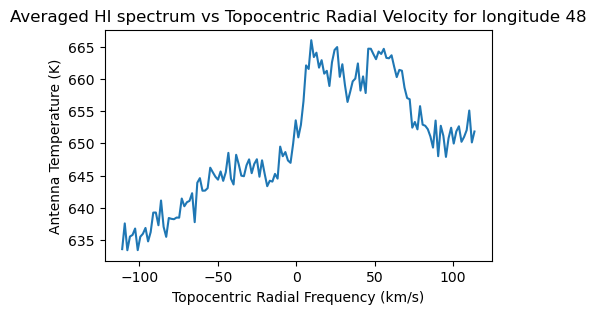

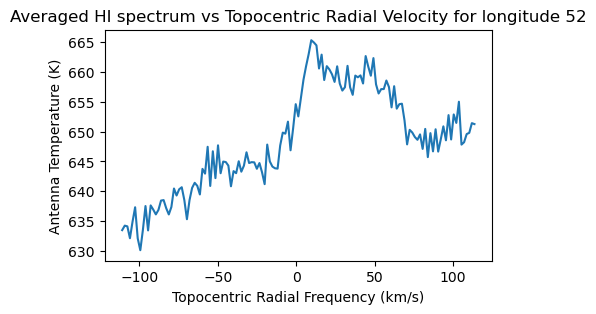

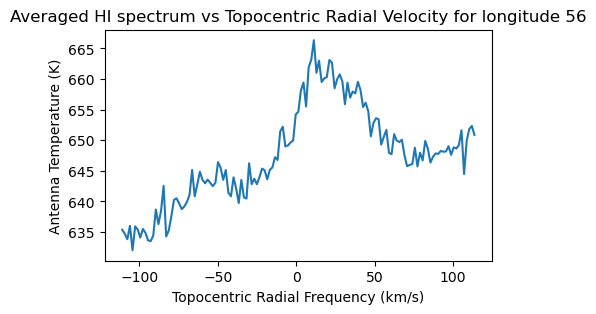

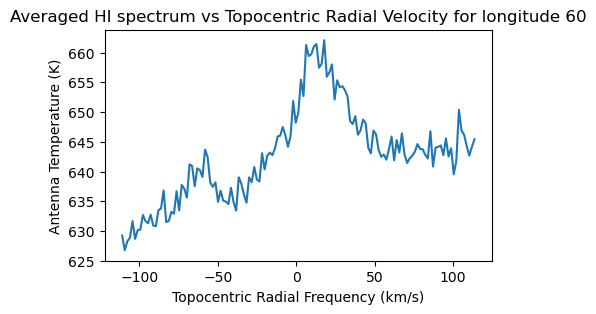

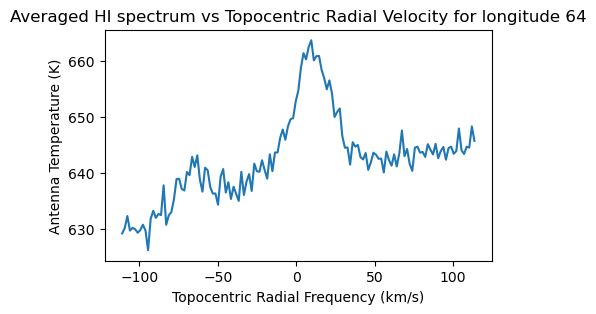

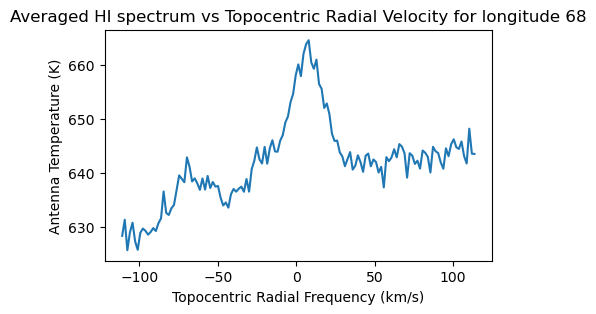

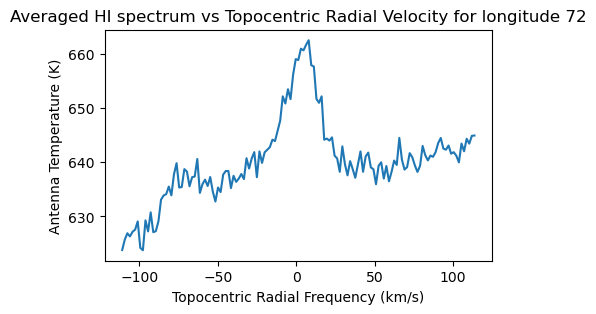

In [17]:
for offset in intensities_per_offset.keys():
    plt.figure(figsize = (5,3))
    plt.plot(intensities_per_offset[offset]["topocentric r velocity"], intensities_per_offset[offset]["avg intensity"])
    plt.xlabel("Topocentric Radial Frequency (km/s)")
    plt.ylabel("Antenna Temperature (K)")
    plt.title(f"Averaged HI spectrum vs Topocentric Radial Velocity for longitude {offset}")
    plt.show()

In [18]:
# -112 to -80 and 80 to 100
indices_1 = np.logical_and(topocentric_r_velocity > -112, topocentric_r_velocity < -80)
indices_2 = np.logical_and(topocentric_r_velocity > 80, topocentric_r_velocity < 100)
baseline_indices = np.logical_or(indices_1, indices_2)
baseline_indices

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

# Part 3

In [22]:
for offset in intensities_per_offset.keys():
    indices_1 = np.logical_and(intensities_per_offset[offset]['topocentric r velocity'] > -112, intensities_per_offset[offset]['topocentric r velocity'] < -80)
    indices_2 = np.logical_and(intensities_per_offset[offset]['topocentric r velocity'] > 80, intensities_per_offset[offset]['topocentric r velocity'] < 100)
    baseline_indices = np.logical_or(indices_1, indices_2)
    intensities_per_offset[offset]['baseline tr'] = intensities_per_offset[offset]['topocentric r velocity'][baseline_indices]
    intensities_per_offset[offset]['baseline freq'] = intensities_per_offset[offset]['frequency'][baseline_indices]
    intensities_per_offset[offset]['baseline int'] = intensities_per_offset[offset]['avg intensity'][baseline_indices]

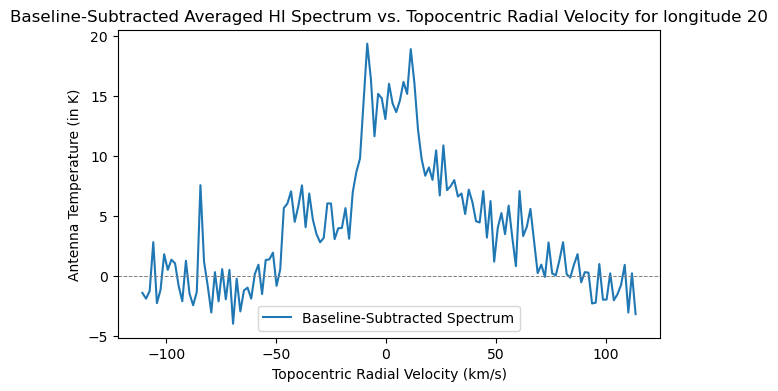

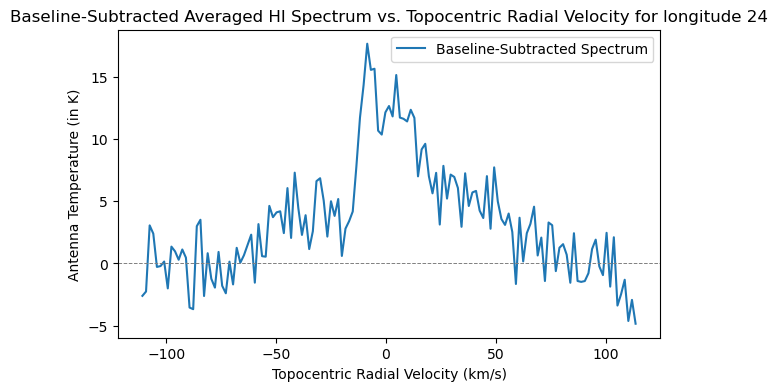

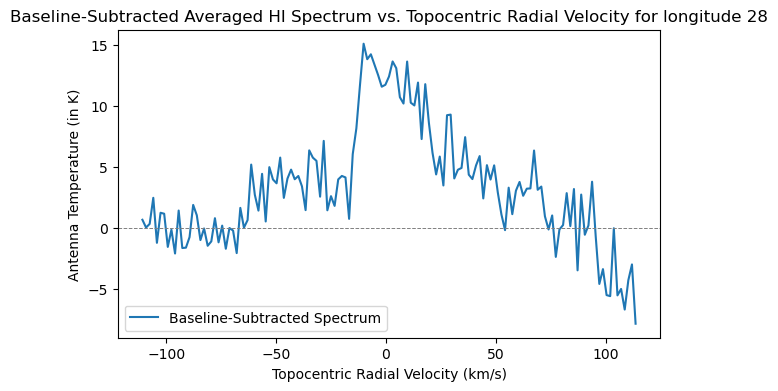

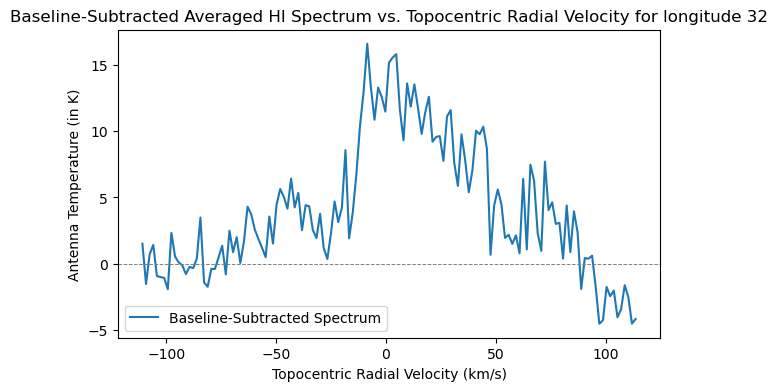

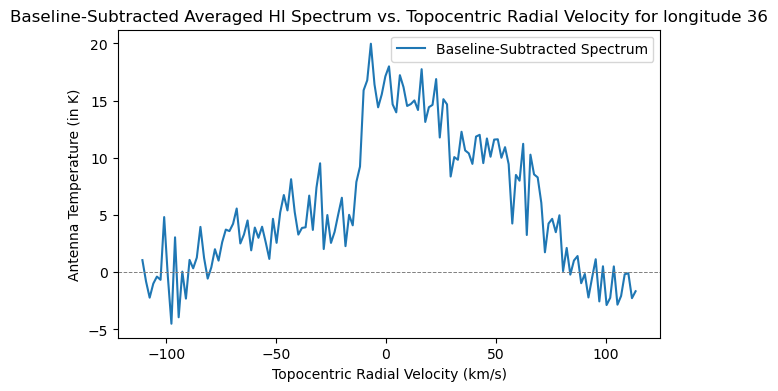

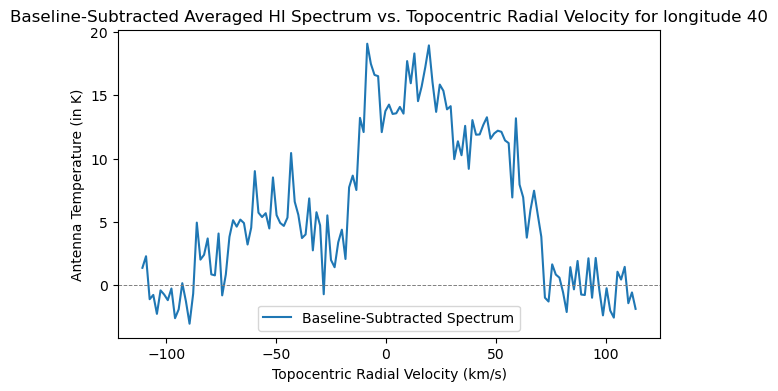

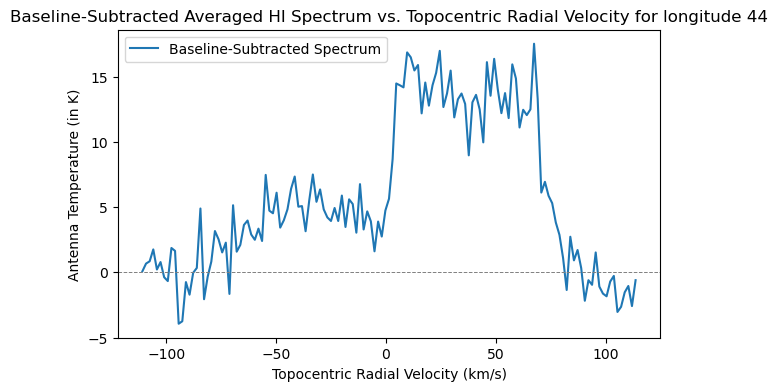

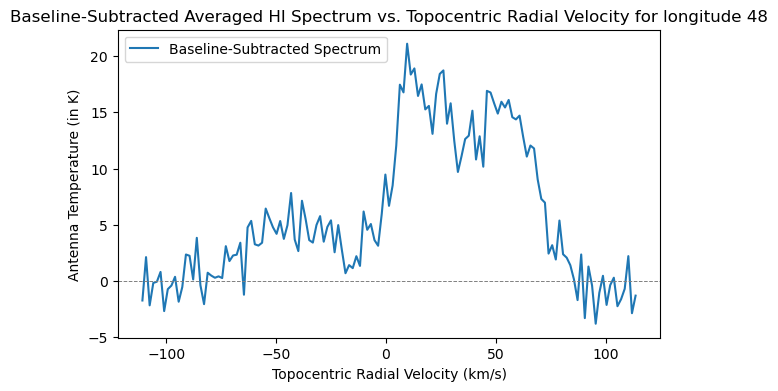

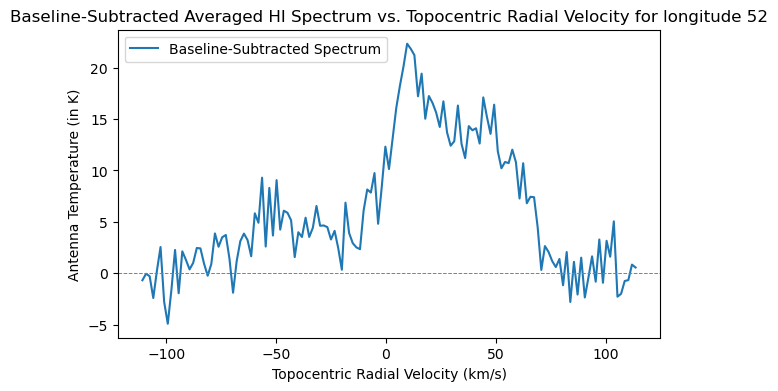

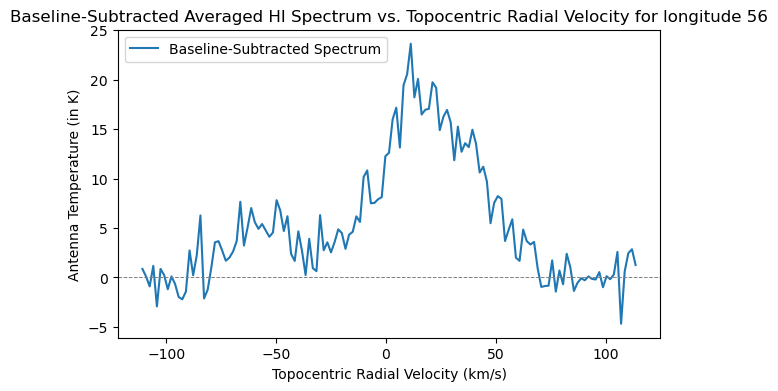

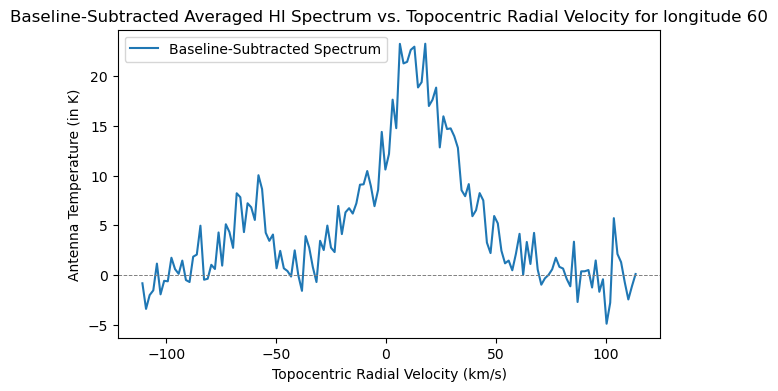

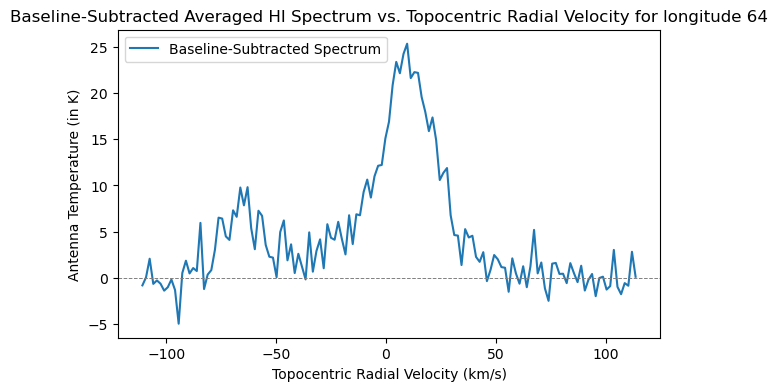

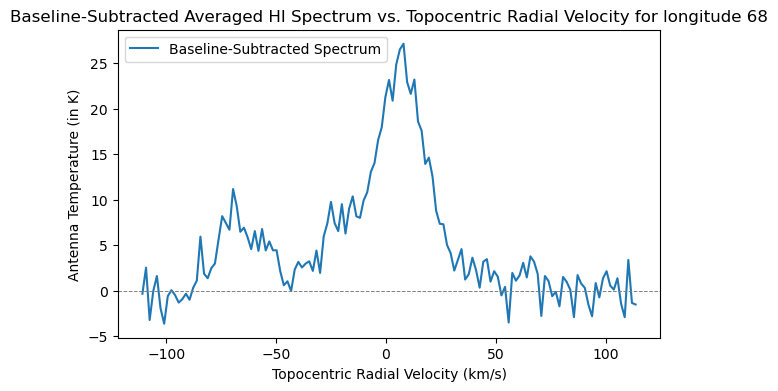

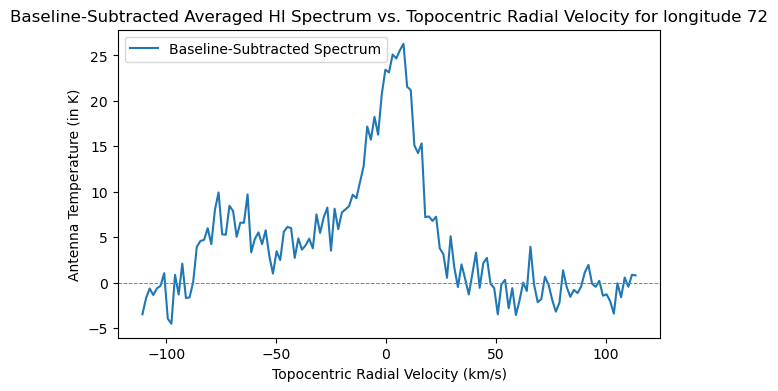

In [23]:
for offset in intensities_per_offset.keys():
    coefficients = np.polyfit(intensities_per_offset[offset]['baseline freq'], intensities_per_offset[offset]['baseline int'], deg=1)
    baseline = np.polyval(coefficients, intensities_per_offset[offset]['frequency'])
    baseline_subtracted_intensity = intensities_per_offset[offset]['avg intensity'] - baseline
    intensities_per_offset[offset]["final int"] = baseline_subtracted_intensity
    plt.figure(figsize = (7, 4))
    plt.plot(intensities_per_offset[offset]['topocentric r velocity'],baseline_subtracted_intensity, label='Baseline-Subtracted Spectrum')
    plt.xlabel("Topocentric Radial Velocity (km/s)")
    plt.ylabel("Antenna Temperature (in K)")
    plt.title(f"Baseline-Subtracted Averaged HI Spectrum vs. Topocentric Radial Velocity for longitude {offset}")
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    plt.legend()
    plt.show()

# Part 4

In [25]:
from astropy.coordinates import SkyCoord, EarthLocation
import numpy as np
from astropy.time import Time
import astropy.units as u

def topo_to_lsr(long, lat = 0):
    Vsun = 20.0
    RAsun = 270.96 * np.pi / 180
    DECsun = 30.004667*np.pi / 180
    target_coord = SkyCoord(l = long*u.degree , b = lat*u.degree, 
                            frame = 'galactic').transform_to('icrs')
    ra = target_coord.ra.value*np.pi / 180
    dec = target_coord.dec.value * np.pi / 180
    helio_corr = target_coord.radial_velocity_correction(kind = 'heliocentric', 
                                                          location = EarthLocation(lat = 43.0731 * u.deg, lon = 89.4012 * u.deg, height = 260.0 * u.m)
                                                          , obstime = Time("2024-11-06")).to(u.km/u.s)
    lsr_cor = Vsun*(np.cos(RAsun - ra)* np.cos(DECsun) * np.cos(dec)
                    + np.sin(DECsun)*np.sin(dec))*(u.km/u.s)
    return lsr_cor+helio_corr

In [27]:
coeff = topo_to_lsr(40)
coeff.value

-5.76598146823461

# Part 5

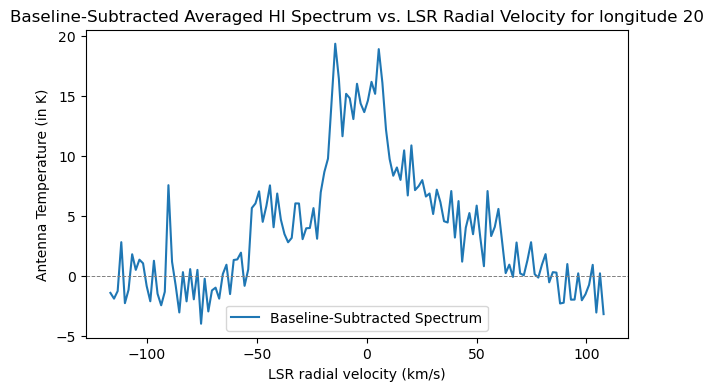

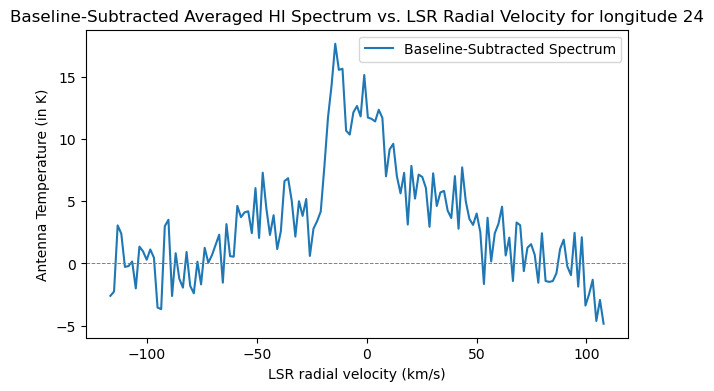

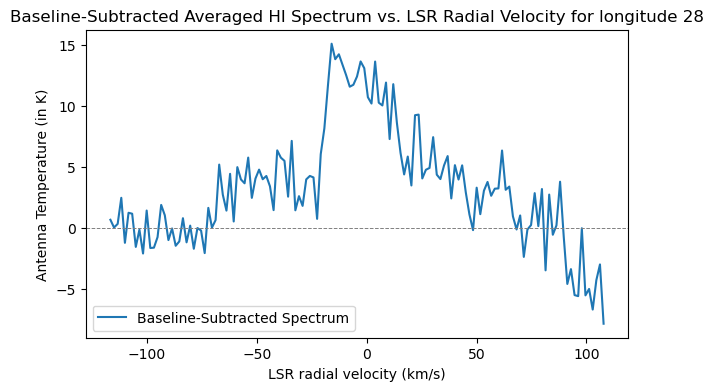

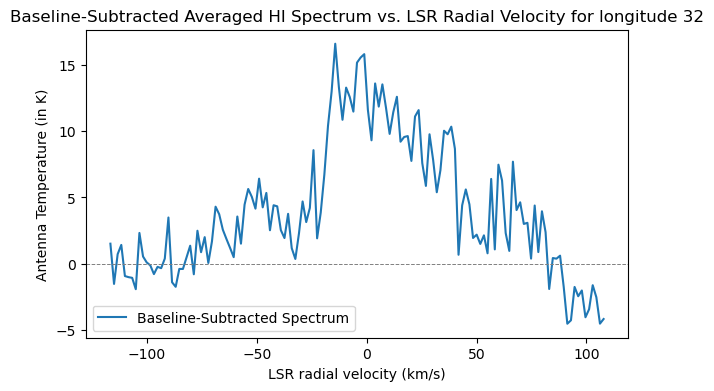

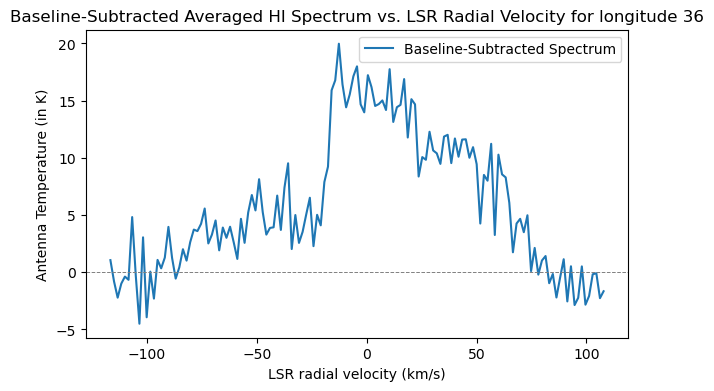

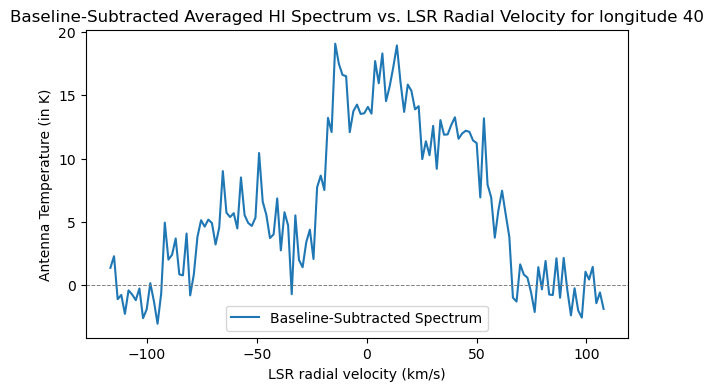

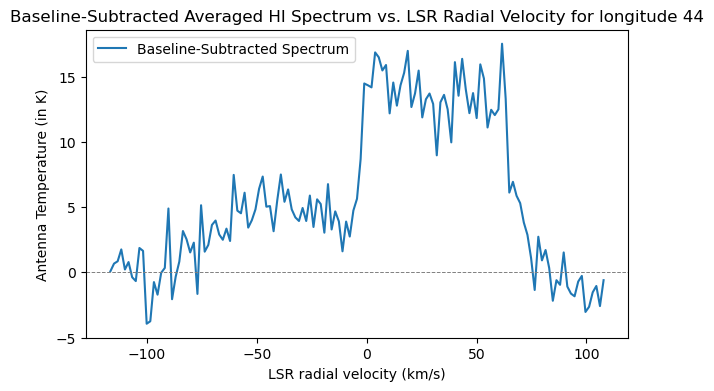

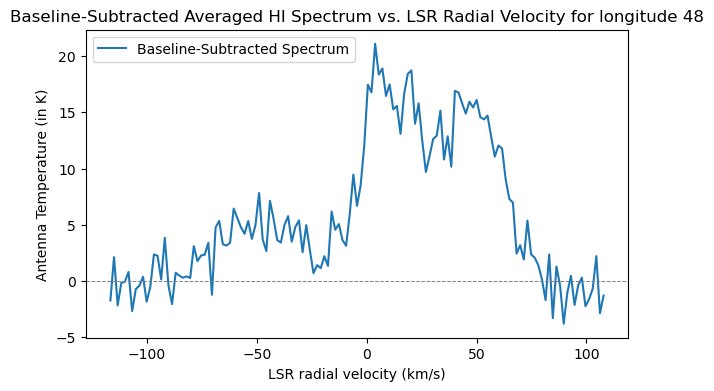

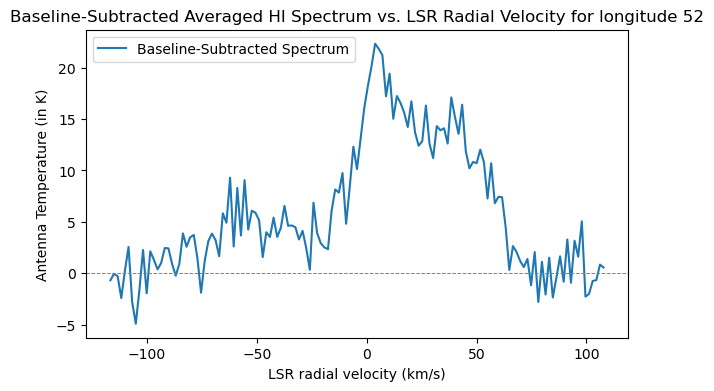

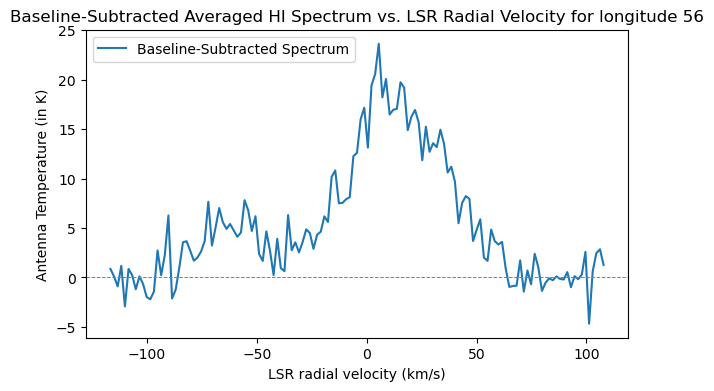

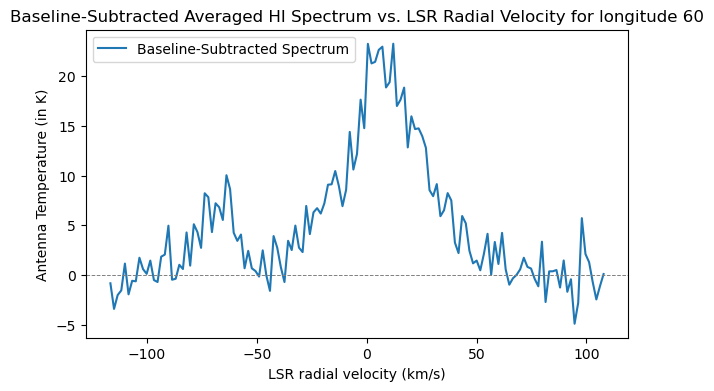

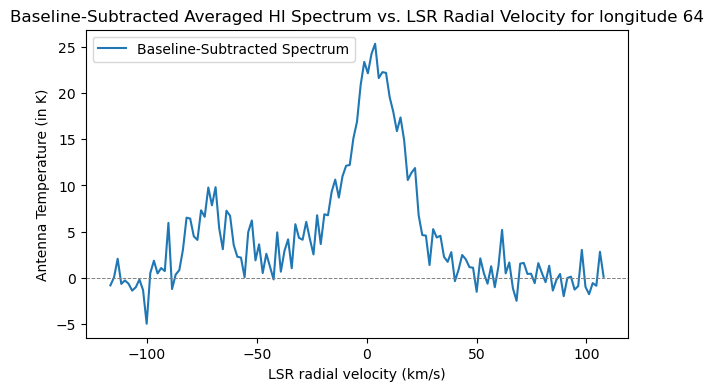

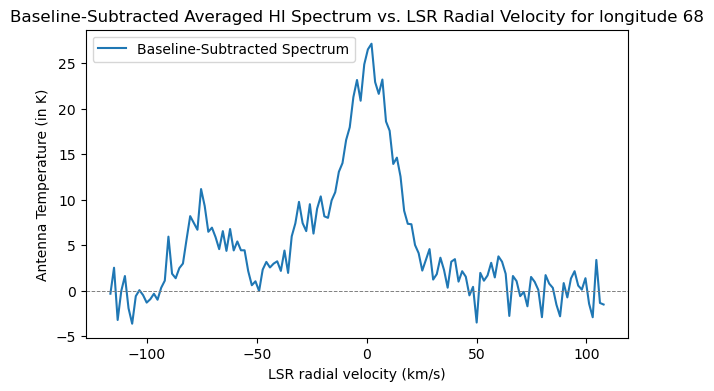

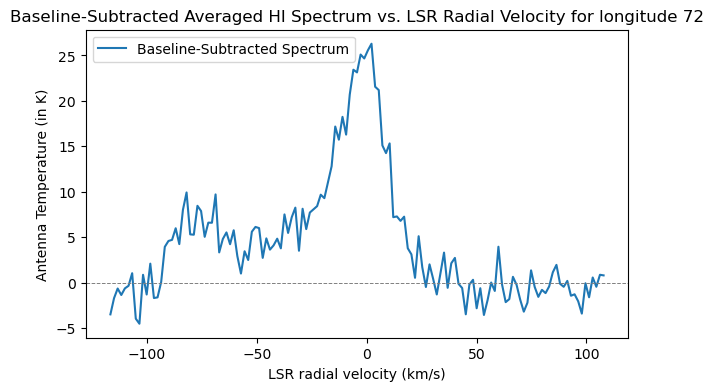

In [31]:
for offset in intensities_per_offset.keys():
    coeff = topo_to_lsr(40).value
    intensities_per_offset[offset]['topocentric r velocity'] = intensities_per_offset[offset]['topocentric r velocity'] + coeff
    plt.figure(figsize = (7, 4))
    plt.plot(intensities_per_offset[offset]['topocentric r velocity'],intensities_per_offset[offset]["final int"], label='Baseline-Subtracted Spectrum')
    plt.xlabel("LSR radial velocity (km/s)")
    plt.ylabel("Antenna Temperature (in K)")
    plt.title(f"Baseline-Subtracted Averaged HI Spectrum vs. LSR Radial Velocity for longitude {offset}")
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    plt.legend()
    plt.show()

# Part 6 - Method 1 - using the intensity threshold 

In [36]:
def find_highest_positive_velocity(velocity, intensity):
    smoothed_intensity = savgol_filter(intensity, 25, 2)
    maxima_indices = argrelextrema(smoothed_intensity, np.greater)[0]
    positive_maxima = [(velocity[i], smoothed_intensity[i]) for i in maxima_indices if velocity[i] > 0]
    if positive_maxima:
        max_velocity = max(positive_maxima, key=lambda x: x[1])[0]
    else:
        max_velocity = None
    return max_velocity

In [37]:
random_motion_correction = 12.3 

tangent_point_data = []

for offset in intensities_per_offset.keys():
    velocity = intensities_per_offset[offset]['topocentric r velocity']
    intensity = intensities_per_offset[offset]["final int"]
    smoothed_peak = find_highest_positive_velocity(velocity, intensity)
    raw_peak = max(velocity[intensity > 0]) if np.any(intensity > 0) else None
    if smoothed_peak and raw_peak:
        Vr = (smoothed_peak + raw_peak) / 2 - random_motion_correction
        sigma_Vr = abs(smoothed_peak - raw_peak) / 2
    else:
        Vr, sigma_Vr = None, None
    tangent_point_data.append((offset, Vr, sigma_Vr))

In [38]:
tangent_point_data = [tp for tp in tangent_point_data if tp[1] is not None]
offsets, Vr_values, Vr_errors = zip(*tangent_point_data)

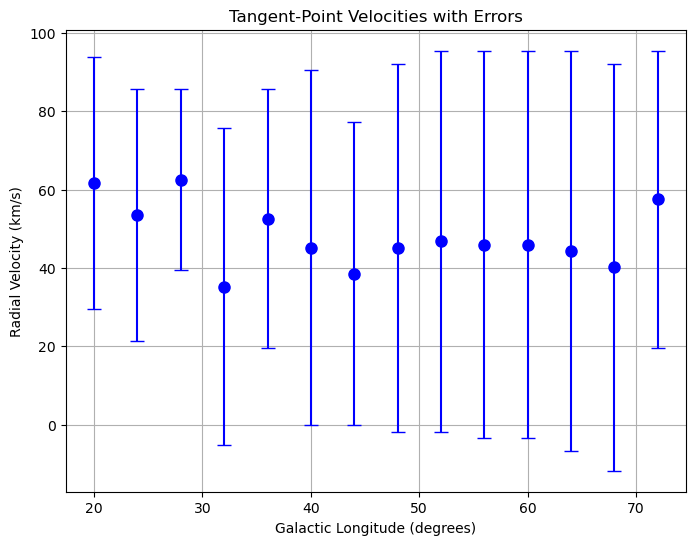

In [41]:
plt.figure(figsize=(8, 6))
plt.errorbar(offsets, Vr_values, yerr=Vr_errors, fmt='o', color='b', markersize=8, capsize=5)
plt.title('Tangent-Point Velocities with Errors')
plt.xlabel('Galactic Longitude (degrees)')
plt.ylabel('Radial Velocity (km/s)')
plt.grid(True)
plt.show()

# Part 6 - Method 2 - using the Gaussian fit

/var/folders/w1/x9k0hbvs5g79qr0pty3j8x6c0000gn/T/ipykernel_8340/3373469536.py:35: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(gaussian, x_subset, y_subset, p0=initial_guess)


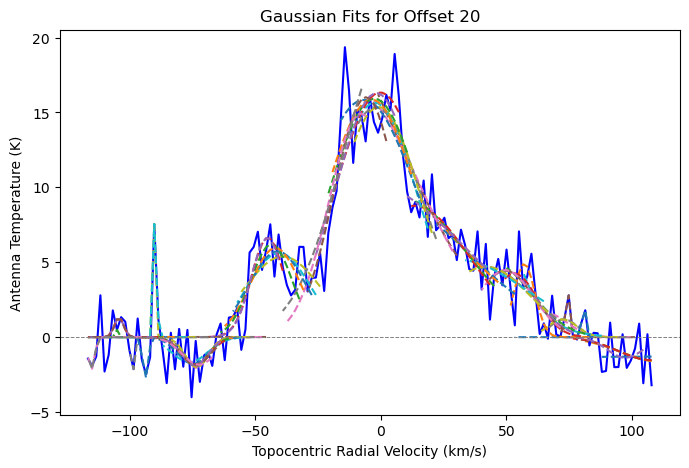

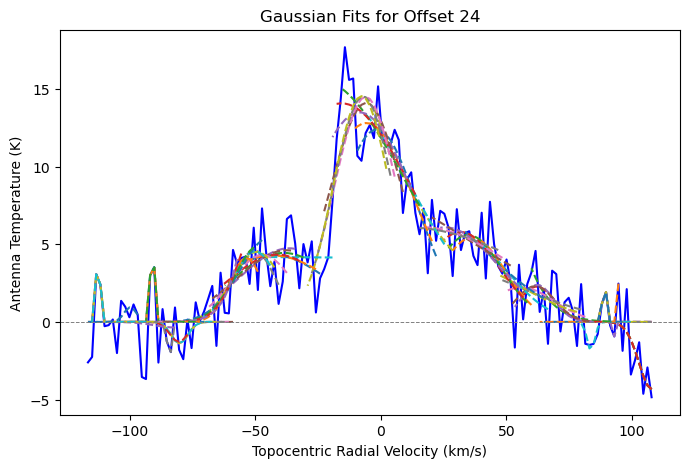

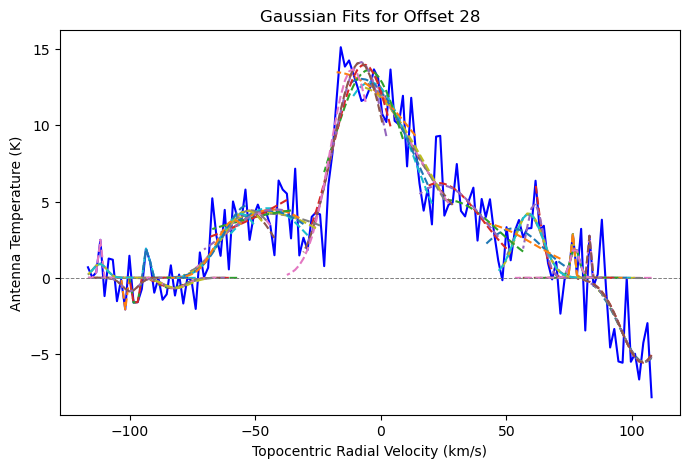

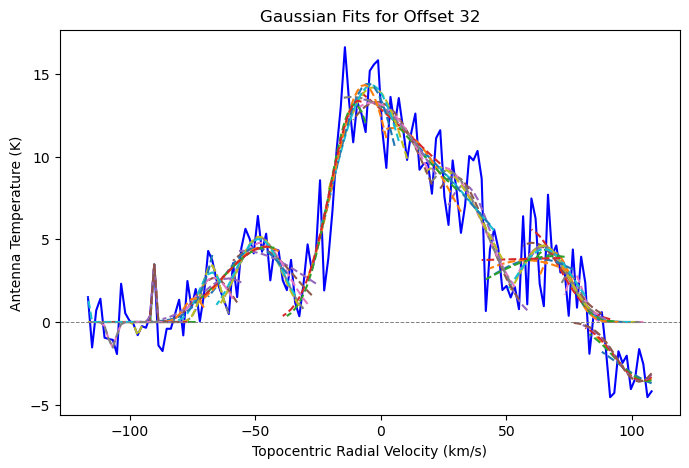

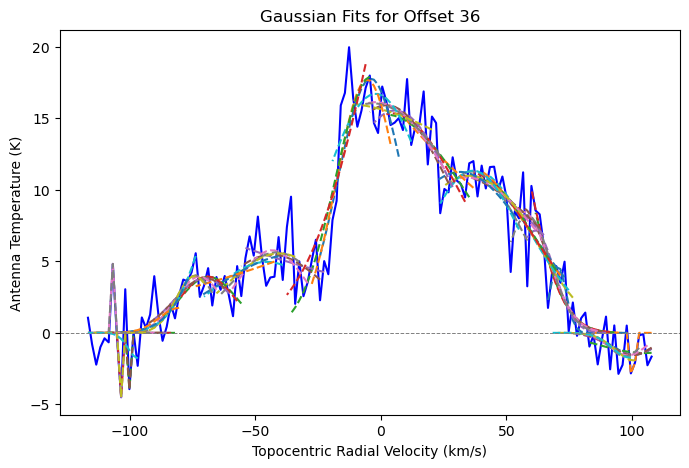

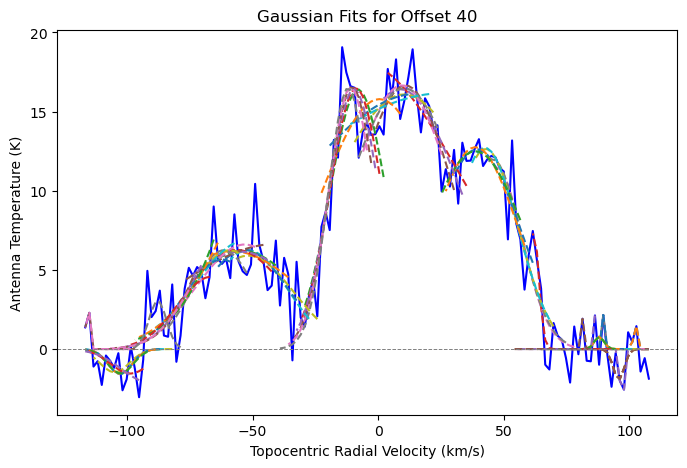

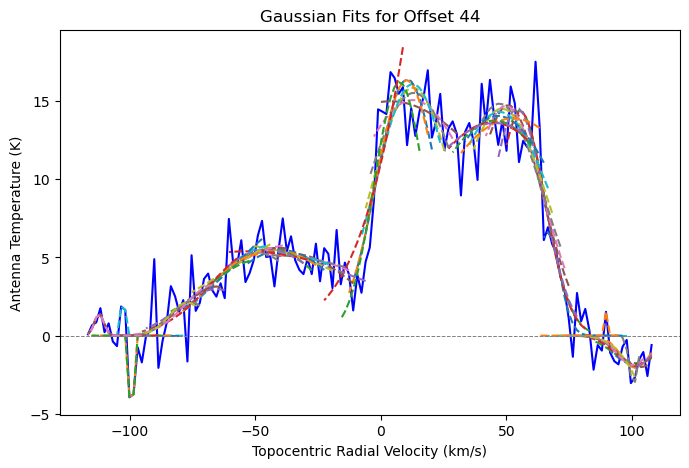

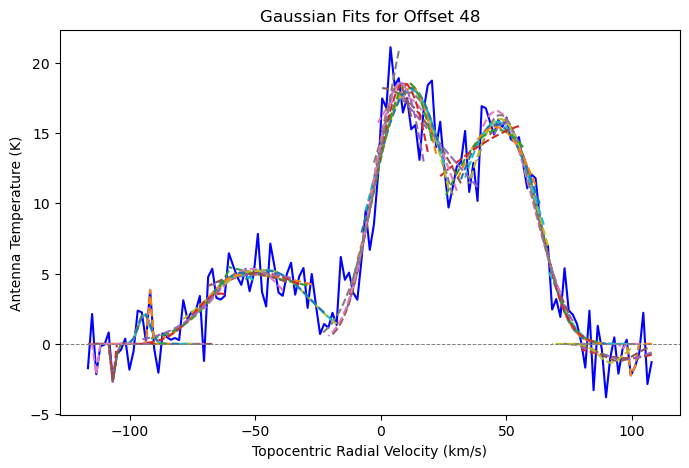

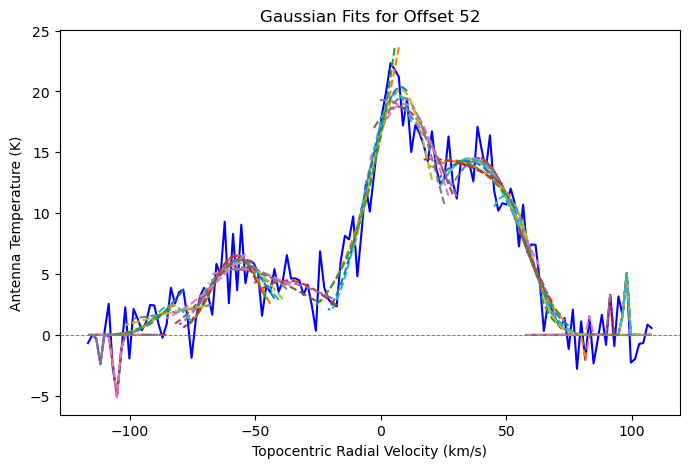

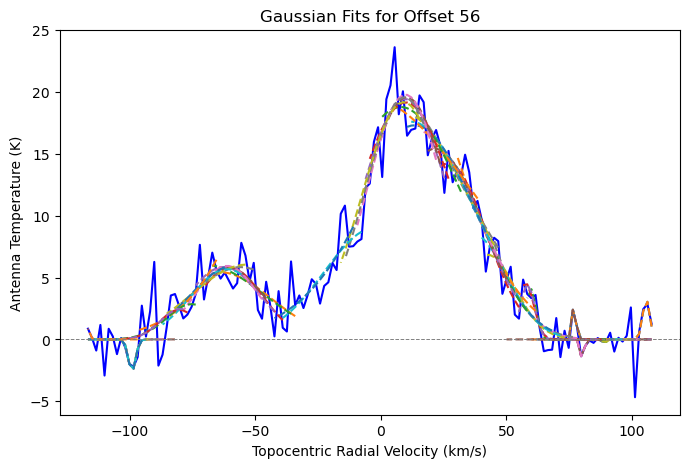

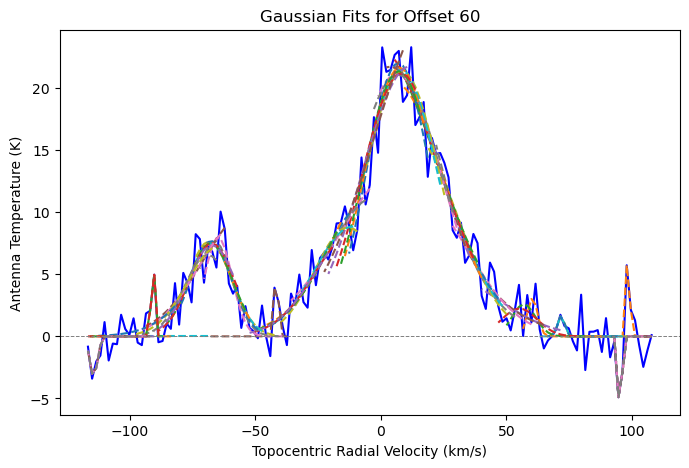

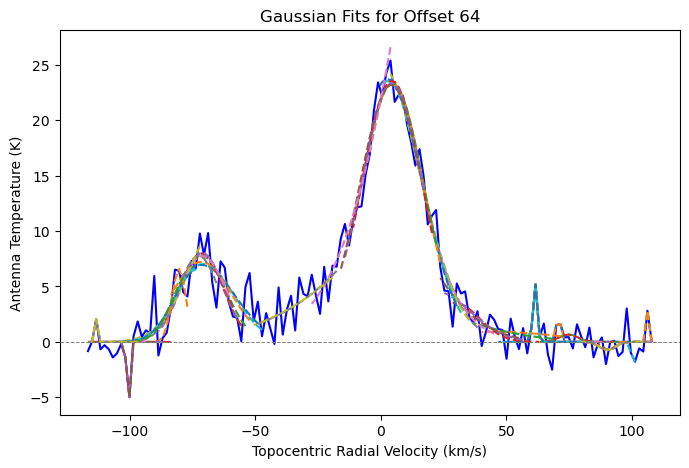

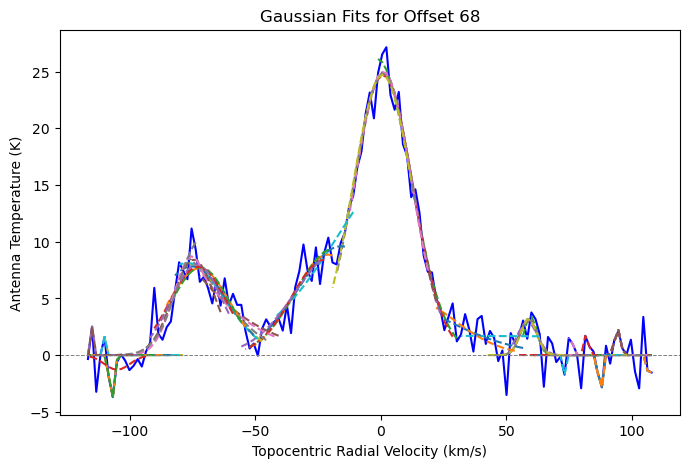

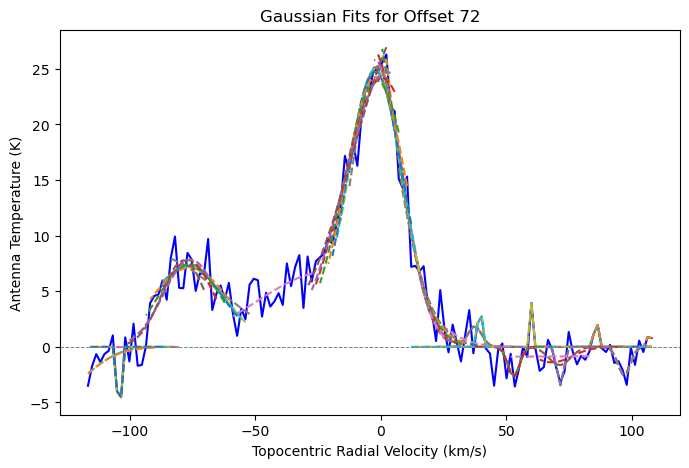

In [45]:
# Define a Gaussian function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-(x - mean)**2 / (2 * sigma**2))

# Loop through each offset and fit multiple Gaussians
for offset in intensities_per_offset.keys():
    velocity = intensities_per_offset[offset]['topocentric r velocity']
    intensity = intensities_per_offset[offset]['final int']
    
    # Find all local maxima (peaks)
    peaks_indices = argrelextrema(intensity, np.greater)[0]
    # Find all local minima (troughs)
    troughs_indices = argrelextrema(intensity, np.less)[0]
    
    # Combine peaks and troughs (optional if you want both)
    all_indices = np.sort(np.concatenate((peaks_indices, troughs_indices)))

    # Plot the original spectrum
    plt.figure(figsize=(8, 5))
    plt.plot(velocity, intensity, color='blue')

    # Fit and plot Gaussians for each peak/trough
    for idx in all_indices:
        # Define a small neighborhood around the peak/trough for fitting
        start_idx = max(0, idx - 10)  # Avoid going out of bounds
        end_idx = min(len(velocity), idx + 10)
        
        x_subset = velocity[start_idx:end_idx]
        y_subset = intensity[start_idx:end_idx]

        # Initial guesses for Gaussian parameters
        initial_guess = [max(y_subset), velocity[idx], 5]  # Amplitude, mean, width
        try:
            # Fit the Gaussian
            popt, _ = curve_fit(gaussian, x_subset, y_subset, p0=initial_guess)

            # Plot the fitted Gaussian
            plt.plot(x_subset, gaussian(x_subset, *popt), linestyle='--', label=f'Gaussian Fit: Peak at {popt[1]:.2f} km/s')
        except RuntimeError:
            continue
    plt.xlabel("Topocentric Radial Velocity (km/s)")
    plt.ylabel("Antenna Temperature (K)")
    plt.title(f"Gaussian Fits for Offset {offset}")
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    plt.show()

# Part 7, 8

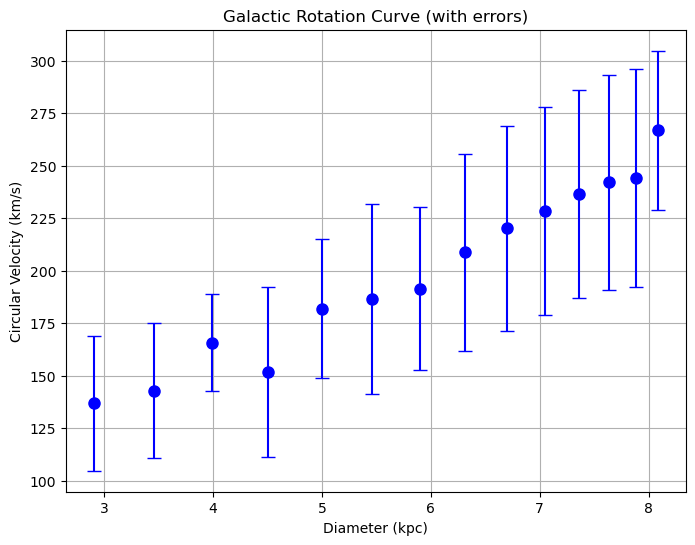

In [49]:
R0 = 8.5
diameters = [R0 * np.sin(np.radians(offset)) for offset in offsets]

V_sun = 220
circular_velocities = [Vr + V_sun * np.sin(np.radians(offset)) for Vr, offset in zip(Vr_values, offsets)]

plt.figure(figsize=(8, 6))
plt.errorbar(diameters, circular_velocities, yerr=Vr_errors, fmt='o', color='b', markersize=8, capsize=5)
plt.title('Galactic Rotation Curve (with errors)')
plt.xlabel('Diameter (kpc)')
plt.ylabel('Circular Velocity (km/s)')
plt.grid(True)
plt.show()

# Part 9

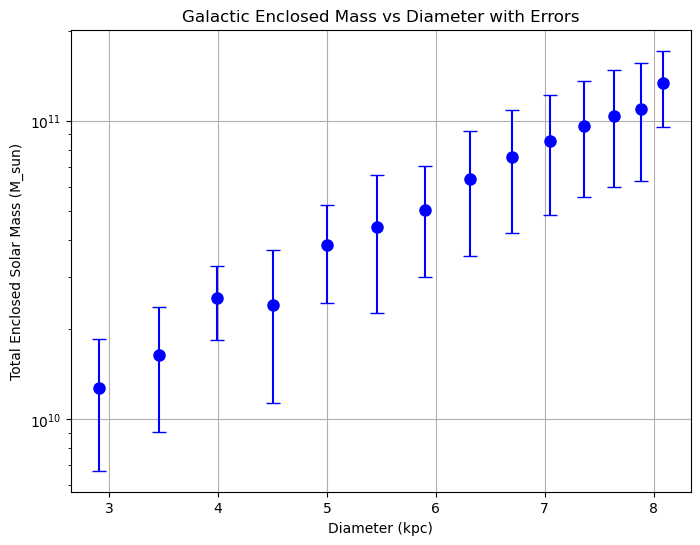

In [63]:
def inclosed_mass(v, r, v_err):
    vel = v * 1000
    rad = r * 3.086e+19
    vel_err = v_err * 1000
    G = 6.674e-11
    mass = (vel**2 * rad) / G
    mass_err = ((2 * vel * vel_err * rad) / G)
    mass_solar = mass / 1.989e+30
    mass_err_solar = mass_err / 1.989e+30
    return mass_solar, mass_err_solar

total_solar_masses = []
total_solar_mass_errors = []

for diameter, velocity, velocity_error in zip(diameters, circular_velocities, Vr_errors):
    mass, mass_error = inclosed_mass(velocity, diameter, velocity_error)
    total_solar_masses.append(mass)
    total_solar_mass_errors.append(mass_error)

plt.figure(figsize=(8, 6))
plt.errorbar(diameters, total_solar_masses, yerr=total_solar_mass_errors, fmt='o', color='b', markersize=8, capsize=5)
plt.yscale("log")
plt.title('Galactic Enclosed Mass vs Diameter with Errors')
plt.xlabel('Diameter (kpc)')
plt.ylabel('Total Enclosed Solar Mass (M_sun)')
plt.grid(True)
plt.show()